In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:\\Users\\user\\ML PROJECTS\Data Sets\\customer_churn.csv")

In [3]:
df.sample(12)

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
13,53,58083.650655,790.426502,27,144.356214,167,88,2,Female,East,0
134,57,51640.921919,670.912704,24,128.667325,288,56,3,Male,North,0
506,29,46685.537393,605.096288,18,130.713746,137,48,4,Male,North,0
193,18,38332.749686,627.437567,31,126.323569,360,89,5,Male,West,0
730,66,39223.891016,711.763314,42,135.705365,227,55,3,Female,North,0
837,27,47195.430455,572.989204,25,153.513221,290,88,4,Male,West,1
763,49,31640.895999,657.304916,28,158.944890,341,30,4,Female,South,0
971,18,89025.246713,599.896801,30,117.285145,166,114,5,Male,South,1
442,45,67925.699434,NaN,27,166.654822,91,99,2,Female,North,0
715,56,58287.349316,651.340344,25,96.421904,16,112,5,Male,South,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    1000 non-null   int64  
 1   income                 951 non-null    float64
 2   credit_score           950 non-null    float64
 3   transactions_month     1000 non-null   int64  
 4   avg_purchase_value     950 non-null    float64
 5   days_since_last_login  1000 non-null   int64  
 6   tenure_months          1000 non-null   int64  
 7   num_products           1000 non-null   int64  
 8   gender                 1000 non-null   str    
 9   region                 1000 non-null   str    
 10  churn                  1000 non-null   int64  
dtypes: float64(3), int64(6), str(2)
memory usage: 95.4 KB


In [5]:
df.shape

(1000, 11)

In [6]:
df.isnull().sum()

age                       0
income                   49
credit_score             50
transactions_month        0
avg_purchase_value       50
days_since_last_login     0
tenure_months             0
num_products              0
gender                    0
region                    0
churn                     0
dtype: int64

In [7]:
# Step 2: Handle Missing Values
numerical_cols_with_na = ['income', 'credit_score', 'avg_purchase_value']
for col in numerical_cols_with_na:
    if col in df.columns:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Imputed missing values in '{col}' with median: {median_val}")

    print("\nMissing values after cleaning:")
    print(df.isnull().sum())

Imputed missing values in 'income' with median: 51298.8468120935

Missing values after cleaning:
age                       0
income                    0
credit_score             50
transactions_month        0
avg_purchase_value       50
days_since_last_login     0
tenure_months             0
num_products              0
gender                    0
region                    0
churn                     0
dtype: int64
Imputed missing values in 'credit_score' with median: 650.7467679262613

Missing values after cleaning:
age                       0
income                    0
credit_score              0
transactions_month        0
avg_purchase_value       50
days_since_last_login     0
tenure_months             0
num_products              0
gender                    0
region                    0
churn                     0
dtype: int64
Imputed missing values in 'avg_purchase_value' with median: 119.5857610862929

Missing values after cleaning:
age                      0
income              

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    1000 non-null   int64  
 1   income                 1000 non-null   float64
 2   credit_score           1000 non-null   float64
 3   transactions_month     1000 non-null   int64  
 4   avg_purchase_value     1000 non-null   float64
 5   days_since_last_login  1000 non-null   int64  
 6   tenure_months          1000 non-null   int64  
 7   num_products           1000 non-null   int64  
 8   gender                 1000 non-null   str    
 9   region                 1000 non-null   str    
 10  churn                  1000 non-null   int64  
dtypes: float64(3), int64(6), str(2)
memory usage: 95.4 KB


In [9]:
df["avg_purchase_value"] = df["avg_purchase_value"].fillna(df["avg_purchase_value"].median())


In [10]:
df.isna().sum()

age                      0
income                   0
credit_score             0
transactions_month       0
avg_purchase_value       0
days_since_last_login    0
tenure_months            0
num_products             0
gender                   0
region                   0
churn                    0
dtype: int64

<Axes: >

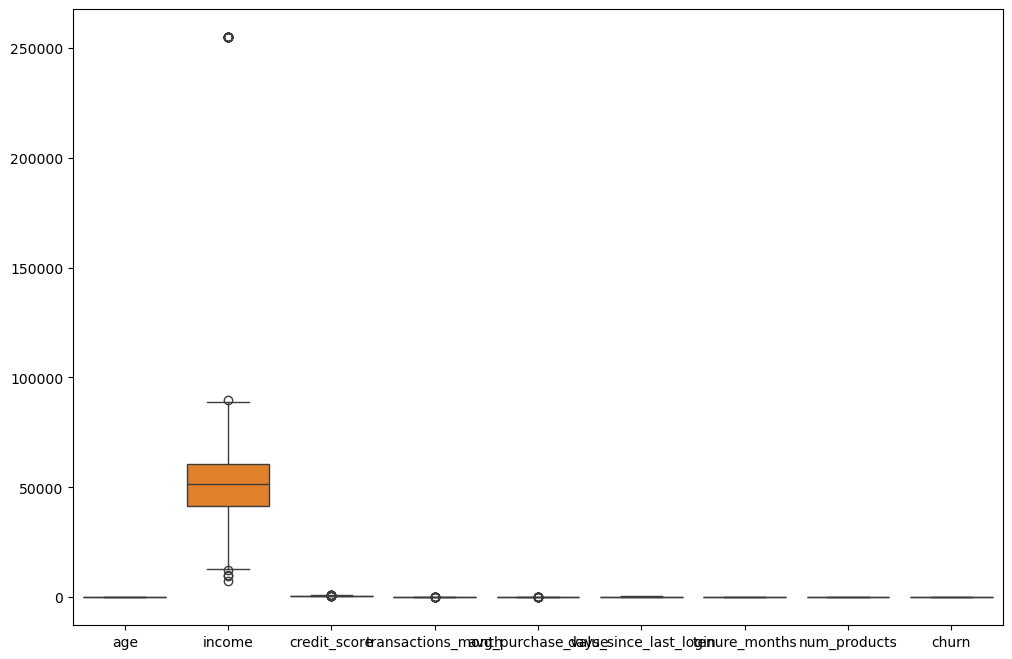

In [11]:
# cheking the out;lier
plt.figure(figsize = (12,8))
sns.boxplot(data = df)


In [12]:
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
for features in numerical_features:
    Q1 =df[features].quantile(0.25)
    Q2 = df[features].quantile(0.50)
    Q3 = df[features].quantile(0.75)
    IQR = Q3 -Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[features] > lower_bound) & (df[features] < upper_bound)]

In [13]:
# replace  the gender column with numerical

df["gender"] = df["gender"].map({"Male": 1, "Female": 0})

In [14]:
# Step 4: One-Hot Encoding
if 'region' in df.columns:
    df = pd.get_dummies(df, columns=['region'], prefix='region', dtype=int)
    print("Applied One-Hot Encoding to 'region'.")

Applied One-Hot Encoding to 'region'.


In [15]:
# Step 4: One-Hot Encoding
    # Apply One-Hot Encoding to nominal categorical columns with multiple categories (e.g., 'region')
if 'region' in df.columns:
    df = pd.get_dummies(df, columns=['region'], prefix='region', dtype=int)
    print("Applied One-Hot Encoding to 'region'.")
        
    # Optional: Drop the original string categorical columns if no longer needed
columns_to_drop = [col for col in ['gender'] if col in df.columns]
if columns_to_drop:
    df = df.drop(columns=columns_to_drop)
    print(f"Dropped original categorical columns: {columns_to_drop}")

    print(f"\nFinal preprocessed dataset shape: {df.shape}")
    print("\nFirst 5 rows of the processed dataset:")
    print(df.head())

Dropped original categorical columns: ['gender']

Final preprocessed dataset shape: (932, 13)

First 5 rows of the processed dataset:
   age        income  credit_score  transactions_month  avg_purchase_value  \
0   56  51298.846812    770.887470                  29           84.828689   
1   69  53051.954538    622.025467                  41          133.943805   
2   46  38654.738821    665.727931                  36          114.993023   
3   32  28666.194356    715.281358                  29          153.875284   
4   60  40301.406736    650.746768                  27          115.391031   

   days_since_last_login  tenure_months  num_products  churn  region_East  \
0                    143             90             1      1            0   
1                     72             96             4      1            1   
2                    155             88             3      1            0   
3                     76            110             2      0            0   
4           

In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 932 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    932 non-null    int64  
 1   income                 932 non-null    float64
 2   credit_score           932 non-null    float64
 3   transactions_month     932 non-null    int64  
 4   avg_purchase_value     932 non-null    float64
 5   days_since_last_login  932 non-null    int64  
 6   tenure_months          932 non-null    int64  
 7   num_products           932 non-null    int64  
 8   churn                  932 non-null    int64  
 9   region_East            932 non-null    int64  
 10  region_North           932 non-null    int64  
 11  region_South           932 non-null    int64  
 12  region_West            932 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 101.9 KB


### Target Column = CHURN

Business Definition: In customer analytics and machine learning, "churn" means whether a customer leaves or stops using a service (usually represented as 0 if they stay, and 1 if they leave). Predicting whether a customer will churn is one of the most common business problems.

In [17]:
# encoding part is done so now we move to model training part before that we nee dto split the data  ( drop the column that target column)
X = df.drop(columns = ["churn"])
y = df["churn"]

In [18]:
# before training we  need to split thhe data into a [Train Test and Split]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(745, 12) (187, 12)
(745,) (187,)


In [19]:
print("Number of rows in X:", len(X))
print("Number of rows in df:", len(df))

Number of rows in X: 932
Number of rows in df: 932


# +++++++++=============================++++++++++

### unfortunatility  the data missused so iam starting again 

In [20]:
df = pd.read_csv("C:\\Users\\user\\ML PROJECTS\\Data Sets\\customer_churn.csv")

In [21]:
#cecking the nulll values
df.isna().sum()

age                       0
income                   49
credit_score             50
transactions_month        0
avg_purchase_value       50
days_since_last_login     0
tenure_months             0
num_products              0
gender                    0
region                    0
churn                     0
dtype: int64

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    1000 non-null   int64  
 1   income                 951 non-null    float64
 2   credit_score           950 non-null    float64
 3   transactions_month     1000 non-null   int64  
 4   avg_purchase_value     950 non-null    float64
 5   days_since_last_login  1000 non-null   int64  
 6   tenure_months          1000 non-null   int64  
 7   num_products           1000 non-null   int64  
 8   gender                 1000 non-null   str    
 9   region                 1000 non-null   str    
 10  churn                  1000 non-null   int64  
dtypes: float64(3), int64(6), str(2)
memory usage: 95.4 KB


In [23]:
# cheking the dupicates
df.duplicated().sum()

np.int64(0)

In [24]:
df.head()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
0,56,NaN,770.887470,29,84.828689,143,90,1,Male,South,1
1,69,53051.954538,622.025467,41,133.943805,72,96,4,Female,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,Male,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,Male,South,0
4,60,40301.406736,NaN,27,115.391031,168,99,2,Male,East,1


In [25]:
df.describe()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,churn
count,1000.00000,951.000000,950.000000,1000.000000,950.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,43.81900,55354.417513,651.422837,29.842000,119.301574,182.155000,60.394000,3.129000,0.517000
std,14.99103,32708.500386,68.271995,5.453511,39.619144,104.205824,34.163166,1.410088,0.499961
min,18.00000,7271.860691,444.172796,15.000000,-7.068153,0.000000,1.000000,1.000000,0.000000
25%,31.00000,40959.853770,605.096009,26.000000,93.330104,88.000000,31.000000,2.000000,0.000000
50%,44.00000,51298.846812,650.746768,30.000000,119.585761,184.000000,61.000000,3.000000,1.000000
75%,56.00000,61285.465584,697.845647,33.000000,146.374081,273.250000,89.250000,4.000000,1.000000
max,69.00000,254852.478291,873.517530,49.000000,244.516408,364.000000,119.000000,5.000000,1.000000


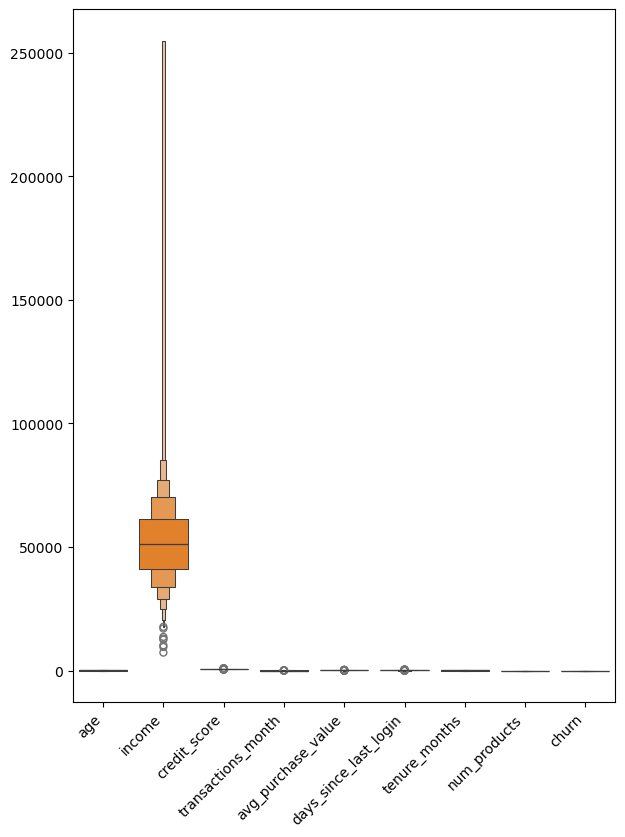

In [26]:
plt.figure(figsize=(7, 9))
sns.boxenplot(data = df)
plt.xticks(rotation=45, ha='right')
plt.show()

In [27]:
#  There is a null values  so we need to fill it with meadian or mean
# There is a 3 numerical columns sow we need to fill it with meadian or mean

df["income"] = df["income"].fillna(df["income"].median())
df["credit_score"] = df["credit_score"].fillna(df["credit_score"].median())
df["avg_purchase_value"] = df["avg_purchase_value"].fillna(df["avg_purchase_value"].median())

AFTER THE FILLING THE NULL VALUES
____________________________________________________________________________________________________


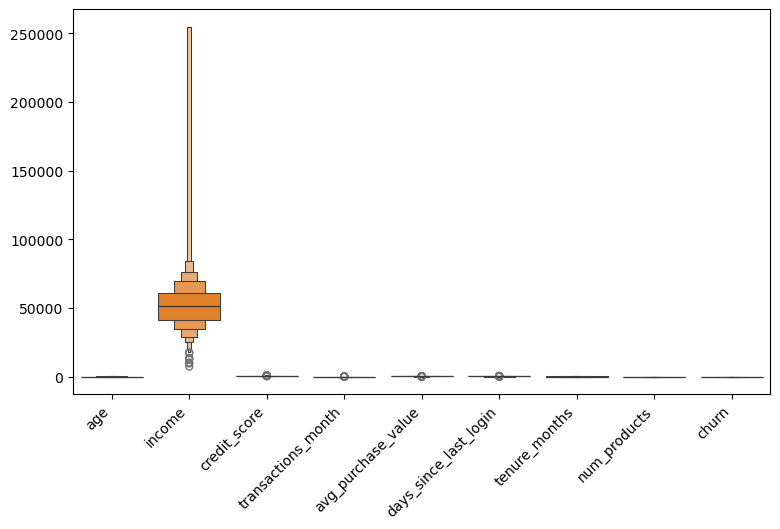

In [28]:
# after filling the nulls
print("AFTER THE FILLING THE NULL VALUES")
print("__"*50)
plt.figure(figsize=(9, 5))
sns.boxenplot(data = df)
plt.xticks(rotation=45, ha='right')
plt.show()

In [29]:
# now we need to cheeck  the null values
df.isna().sum()

age                      0
income                   0
credit_score             0
transactions_month       0
avg_purchase_value       0
days_since_last_login    0
tenure_months            0
num_products             0
gender                   0
region                   0
churn                    0
dtype: int64

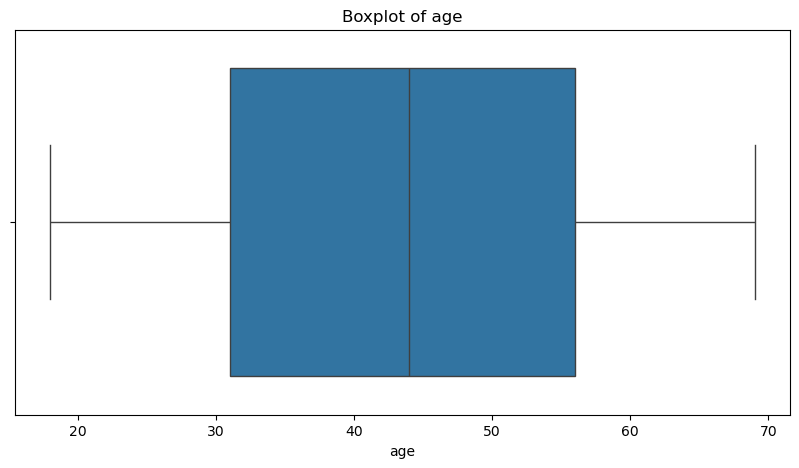

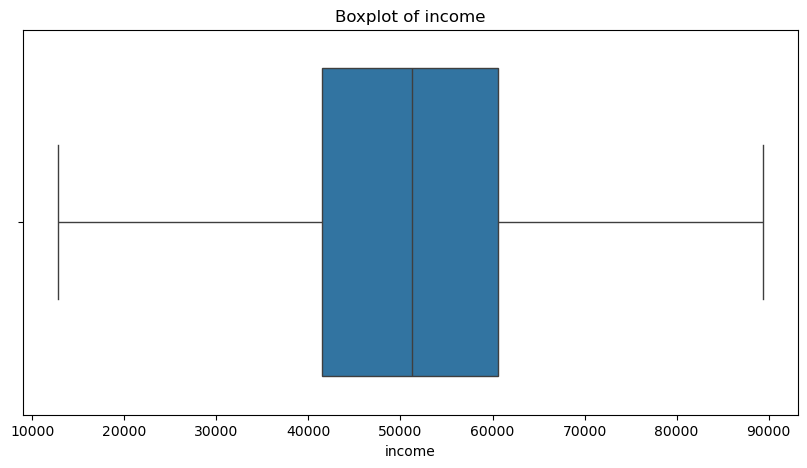

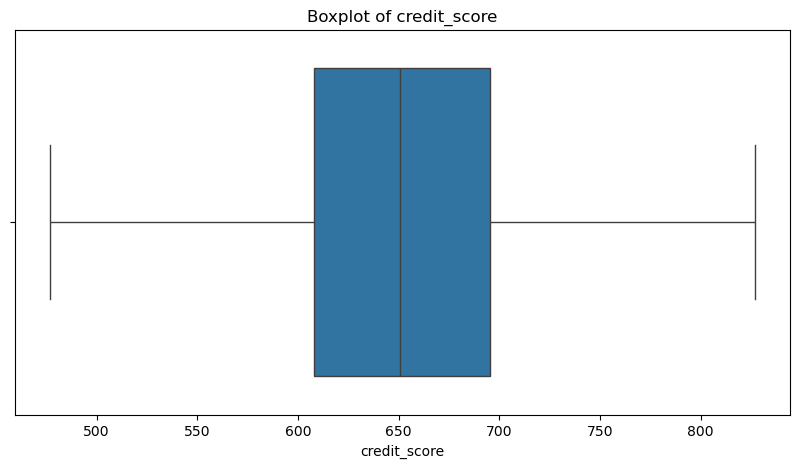

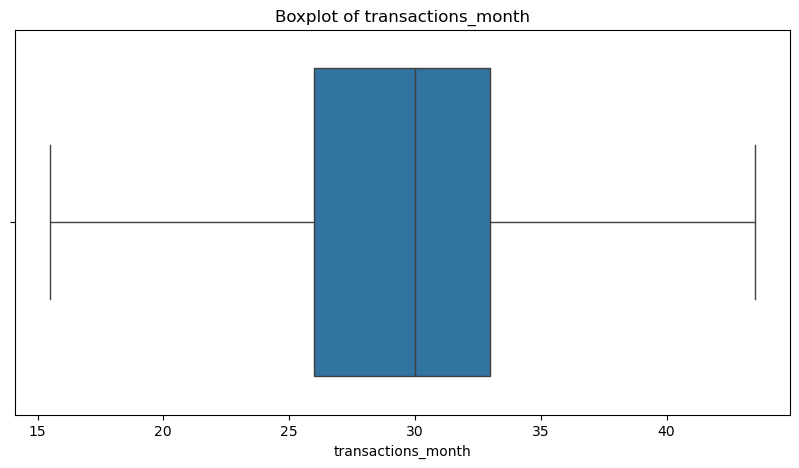

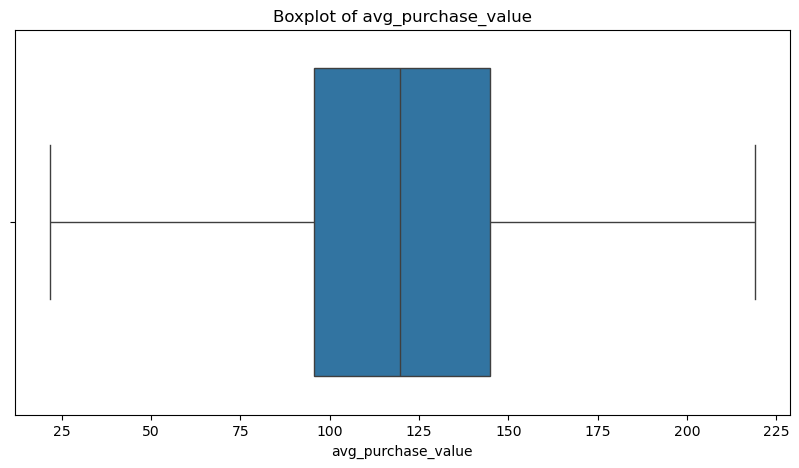

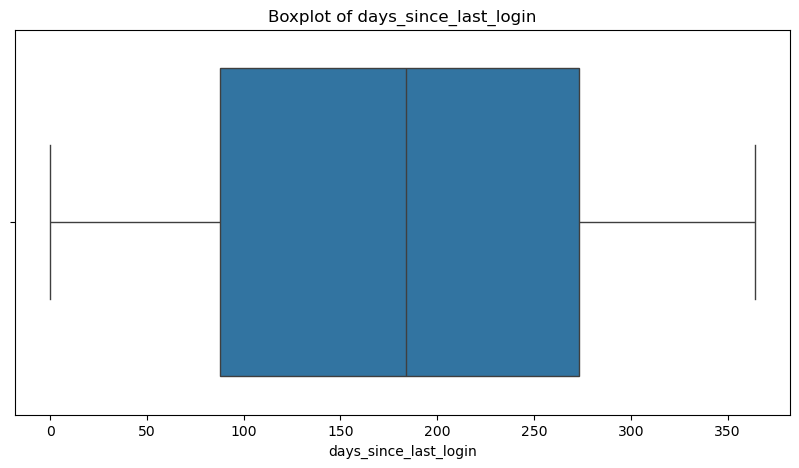

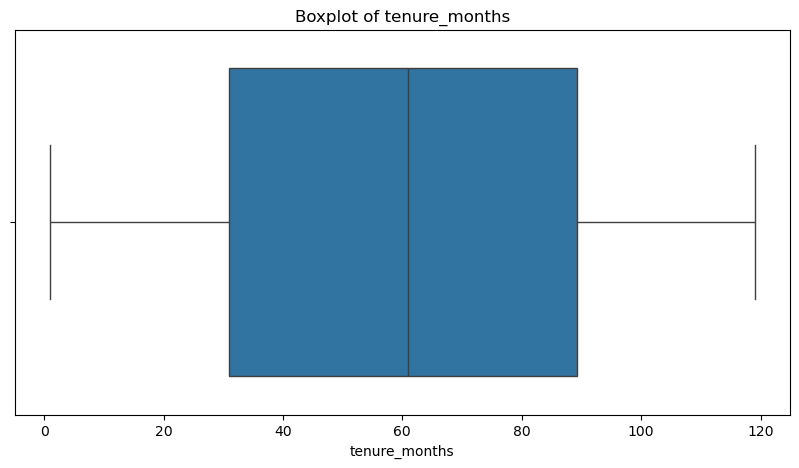

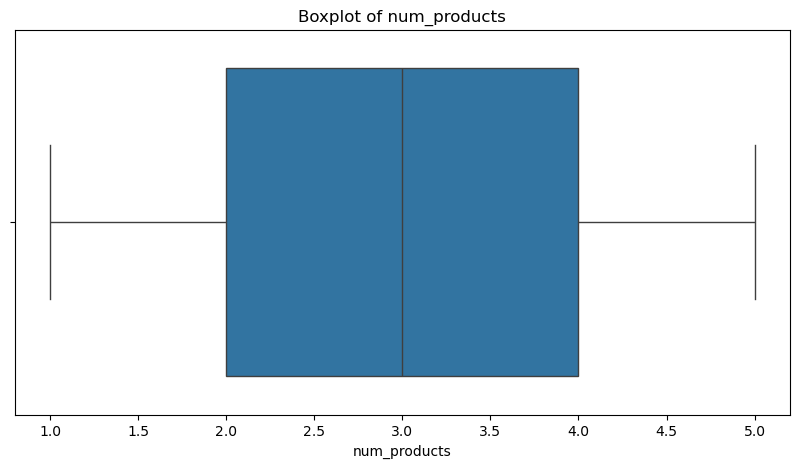

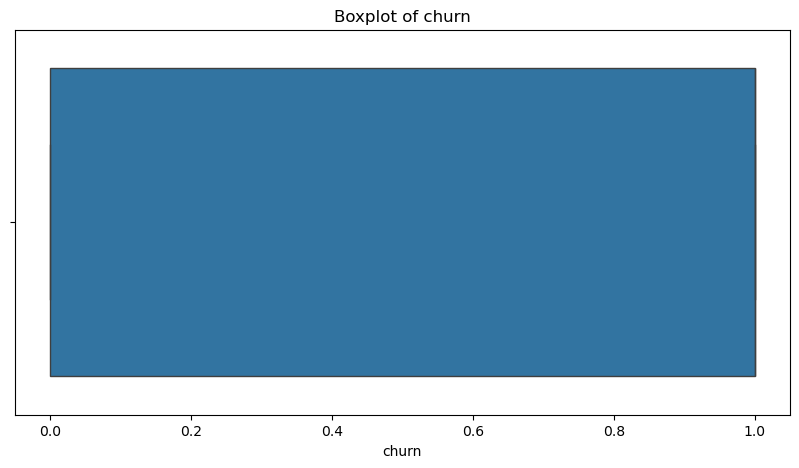

In [30]:
#  now we need to  handel the outliers

for col in df.select_dtypes(include=["float64", "int64"]).columns:
    Q1 = df[col].quantile(0.25)
    Q2 = df[col].quantile(0.50)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR 
    
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot of {col}")
    plt.show()

outliers everything is complete  now we will check the  unuse column after  that encoding 

In [31]:
df.columns

Index(['age', 'income', 'credit_score', 'transactions_month',
       'avg_purchase_value', 'days_since_last_login', 'tenure_months',
       'num_products', 'gender', 'region', 'churn'],
      dtype='str')

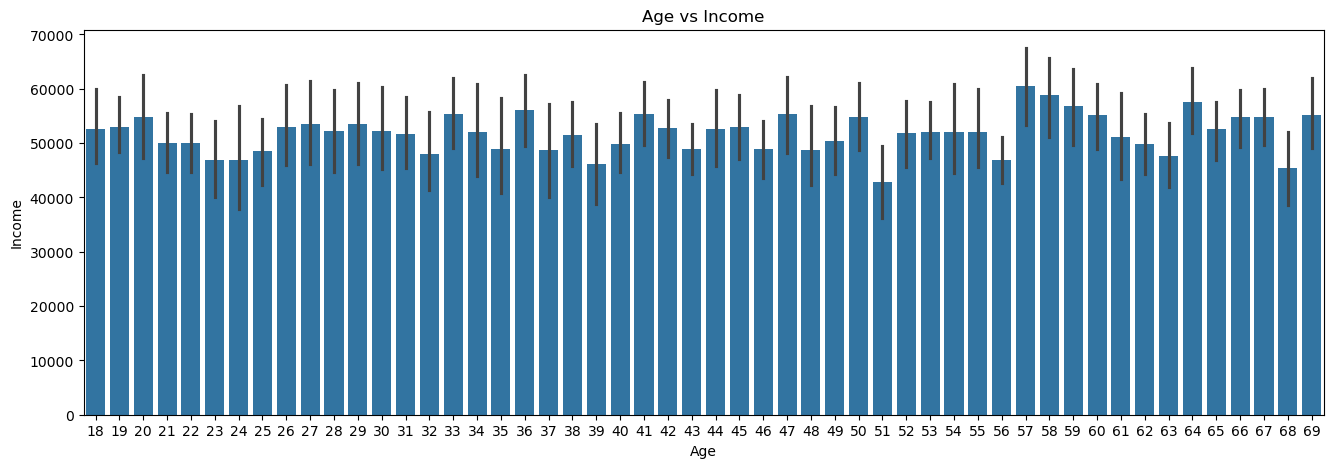

In [32]:
# some EDA  Part 
# Creating the  age  vs income plot

plt.figure(figsize=(16, 5))
sns.barplot(data=df, x='age', y='income')
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Age vs Income')
plt.show()



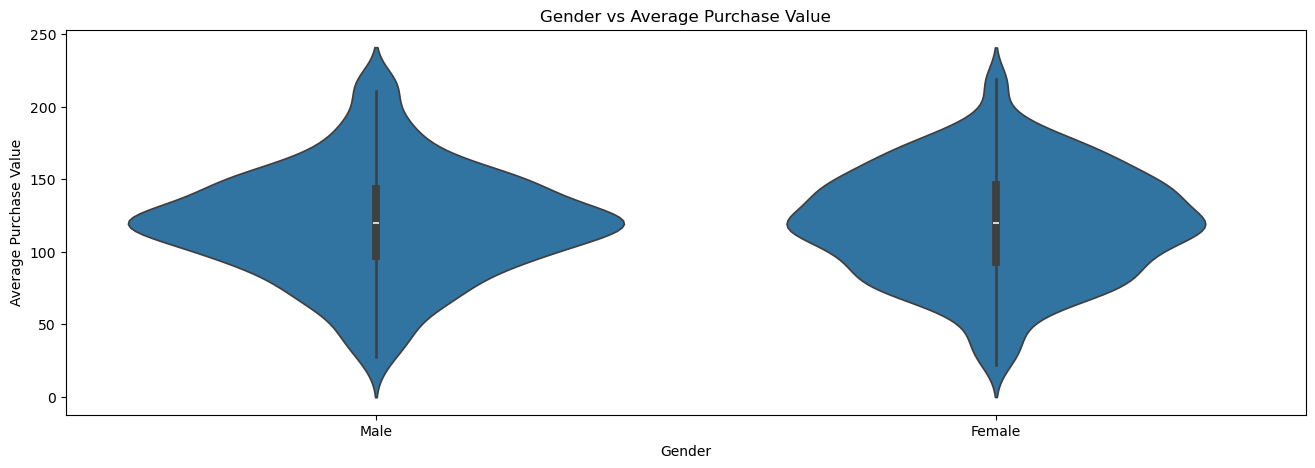

In [33]:
# avg_purchace vs gender 

plt.figure(figsize=(16, 5))
sns.violinplot(data=df, x='gender', y='avg_purchase_value')
plt.xlabel('Gender')
plt.ylabel('Average Purchase Value')
plt.title('Gender vs Average Purchase Value')
plt.show()

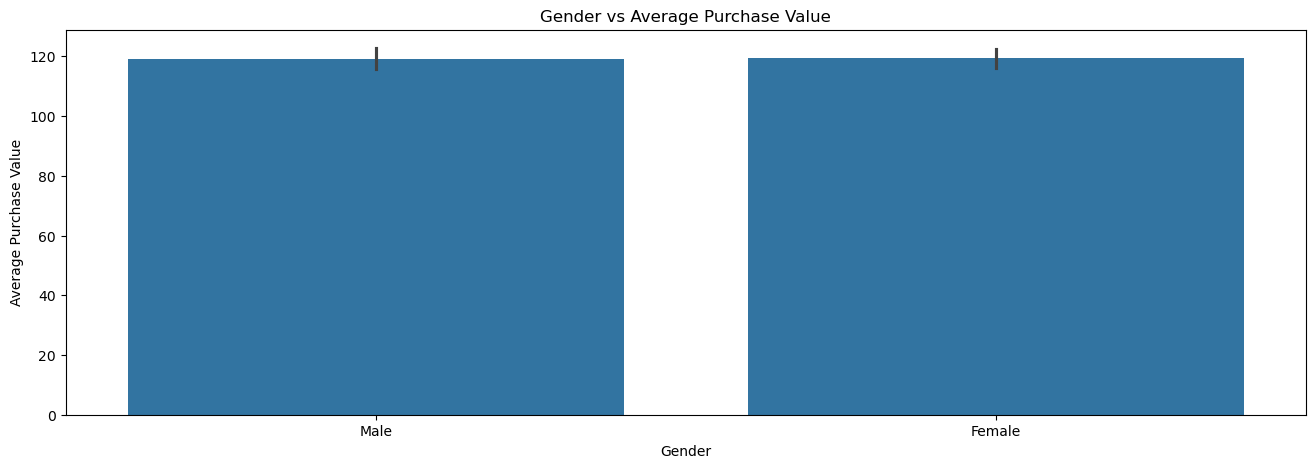

In [34]:
# avg_purchace vs gender 

plt.figure(figsize=(16, 5))
sns.barplot(data=df, x='gender', y='avg_purchase_value')
plt.xlabel('Gender')
plt.ylabel('Average Purchase Value')
plt.title('Gender vs Average Purchase Value')
plt.show()

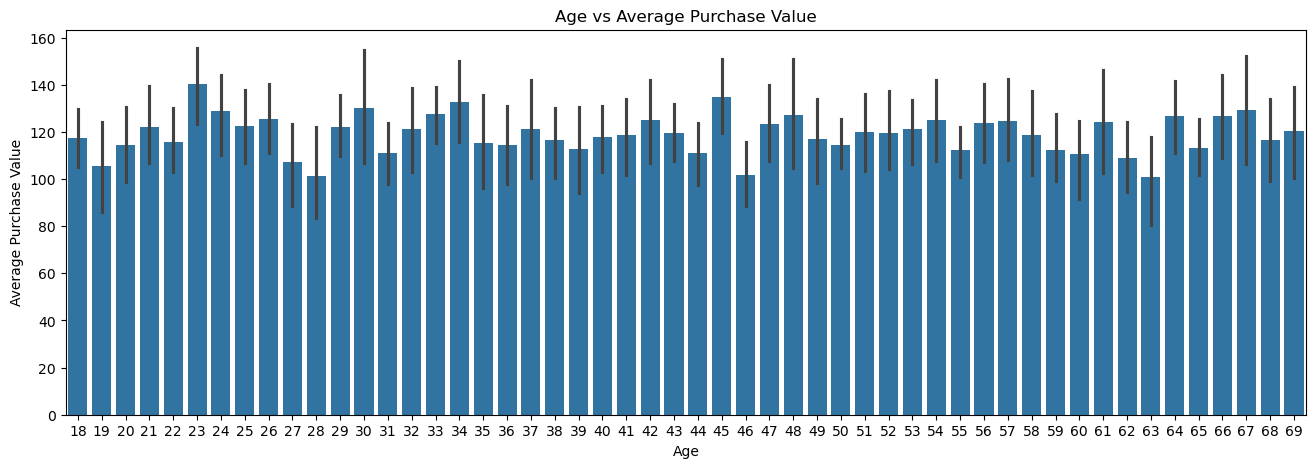

In [35]:
# ctreate  age vs avg_purchase_value

plt.figure(figsize=(16, 5))
sns.barplot(data=df, x='age', y='avg_purchase_value')
plt.xlabel('Age')
plt.ylabel('Average Purchase Value')
plt.title('Age vs Average Purchase Value')
plt.show()

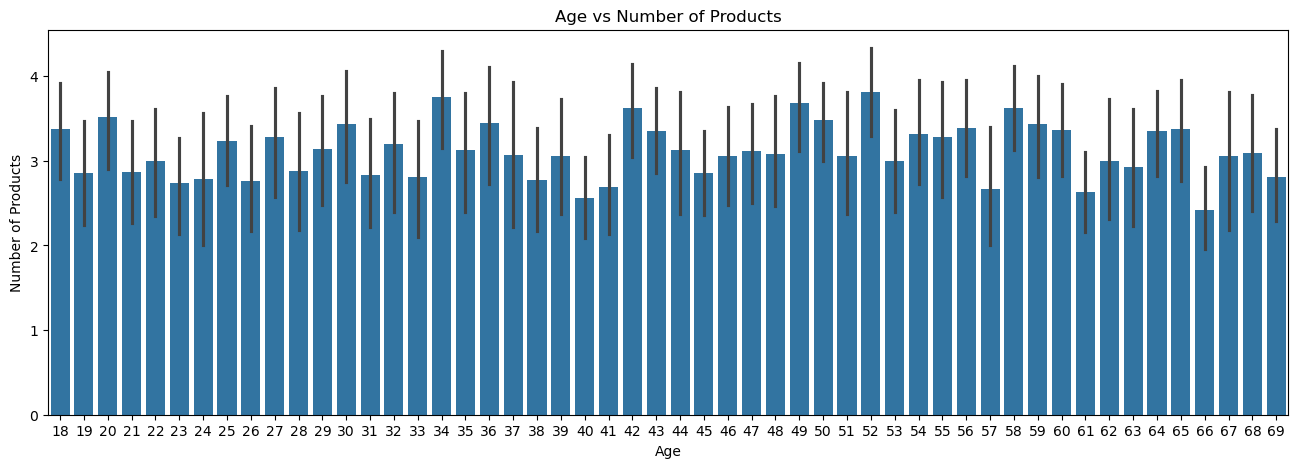

In [36]:
# age vs num_products 

plt.figure(figsize=(16, 5))
sns.barplot(data=df, x='age', y='num_products')
plt.xlabel('Age')
plt.ylabel('Number of Products')
plt.title('Age vs Number of Products')
plt.show()

In [37]:
df["age"].value_counts()

age
45    28
43    28
50    27
52    27
66    26
49    25
18    24
56    23
40    23
41    23
64    23
22    23
68    22
54    22
62    22
69    21
25    21
20    21
19    21
29    21
42    21
33    21
65    21
53    20
34    20
46    19
39    19
61    19
38    18
36    18
47    18
31    18
26    17
28    16
44    16
59    16
67    16
51    16
58    16
30    16
32    15
57    15
35    15
21    15
23    15
55    14
24    14
37    14
27    14
48    13
63    13
60    11
Name: count, dtype: int64

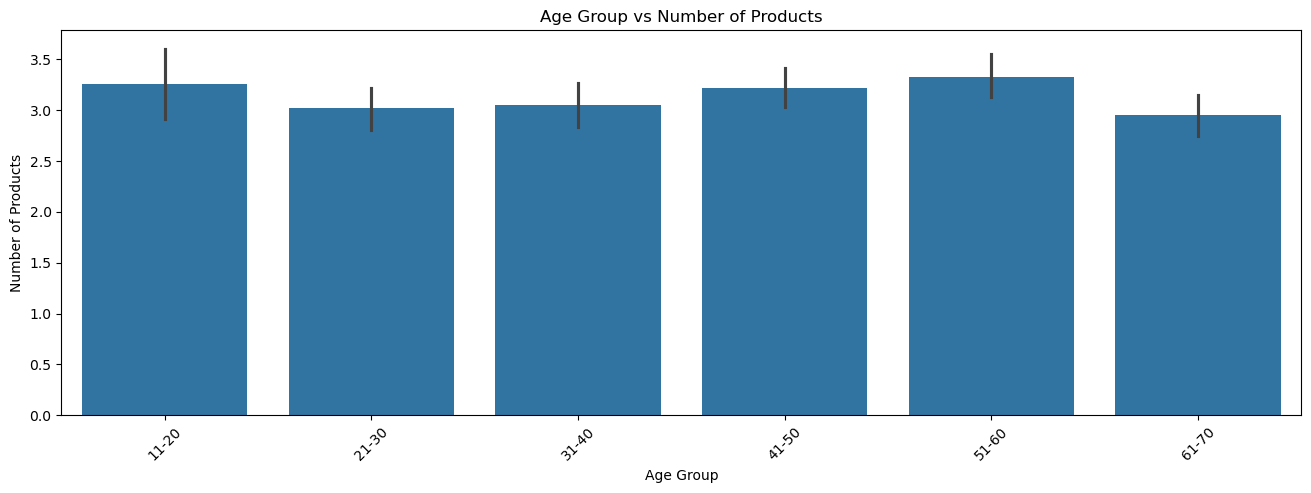

In [38]:
#  Define your bin edges and labels
bins = [10, 20, 30, 40, 50, 60, 70, ]
labels = ['11-20', '21-30', '31-40', '41-50', '51-60', '61-70']

#  Create a new column 'age_group' using pd.cut
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

#  Plot using your new age groups
plt.figure(figsize=(16, 5))
sns.barplot(data=df, x='age_group', y='num_products')

plt.xlabel('Age Group')
plt.ylabel('Number of Products')
plt.title('Age Group vs Number of Products')
plt.xticks(rotation=45)
plt.show()

In [41]:
# now we check the columns and drop unwanted coulumns 
print(df.columns)

# Hear in this  we don't want  the age_group  column so we will drop (it will be cause of multicollinearity | and we create that columm fpr EDA)

df.drop(df['age_group'],axis = 1, inplace=True)

print("-"*55)
print(df.columns)

Index(['age', 'income', 'credit_score', 'transactions_month',
       'avg_purchase_value', 'days_since_last_login', 'tenure_months',
       'num_products', 'gender', 'region', 'churn', 'age_group'],
      dtype='str')


KeyError: "['51-60', '61-70', '41-50', '31-40', '51-60', '21-30', '31-40', '51-60', '31-40', '31-40', '21-30', '21-30', '41-50', '51-60', '51-60', '41-50', '11-20', '31-40', '11-20', '41-50', '61-70', '41-50', '51-60', '11-20', '31-40', '41-50', '21-30', '31-40', '61-70', '41-50', '61-70', '41-50', '51-60', '41-50', '31-40', '31-40', '61-70', '61-70', '61-70', '61-70', '11-20', '51-60', '61-70', '21-30', '31-40', '21-30', '51-60', '31-40', '21-30', '41-50', '31-40', '61-70', '21-30', '41-50', '11-20', '31-40', '41-50', '61-70', '21-30', '61-70', '21-30', '61-70', '51-60', '31-40', '31-40', '51-60', '61-70', '51-60', '21-30', '11-20', '21-30', '51-60', '21-30', '41-50', '31-40', '41-50', '61-70', '51-60', '21-30', '51-60', '31-40', '41-50', '61-70', '31-40', '21-30', '31-40', '31-40', '51-60', '31-40', '31-40', '61-70', '31-40', '61-70', '41-50', '41-50', '41-50', '61-70', '51-60', '41-50', '31-40', '61-70', '11-20', '41-50', '21-30', '21-30', '41-50', '11-20', '61-70', '21-30', '41-50', '21-30', '61-70', '31-40', '21-30', '51-60', '51-60', '41-50', '21-30', '51-60', '51-60', '51-60', '41-50', '21-30', '21-30', '21-30', '21-30', '51-60', '41-50', '61-70', '31-40', '41-50', '51-60', '51-60', '61-70', '51-60', '31-40', '41-50', '51-60', '11-20', '51-60', '51-60', '61-70', '31-40', '11-20', '11-20', '21-30', '41-50', '31-40', '51-60', '41-50', '21-30', '31-40', '31-40', '41-50', '51-60', '21-30', '61-70', '41-50', '51-60', '61-70', '61-70', '41-50', '21-30', '41-50', '51-60', '31-40', '51-60', '61-70', '31-40', '51-60', '41-50', '51-60', '21-30', '41-50', '21-30', '61-70', '31-40', '41-50', '11-20', '51-60', '61-70', '21-30', '41-50', '41-50', '61-70', '61-70', '31-40', '41-50', '21-30', '41-50', '41-50', '51-60', '41-50', '11-20', '41-50', '61-70', '21-30', '51-60', '11-20', '51-60', '21-30', '21-30', '41-50', '21-30', '51-60', '41-50', '61-70', '51-60', '61-70', '41-50', '31-40', '41-50', '41-50', '41-50', '51-60', '61-70', '61-70', '61-70', '61-70', '21-30', '51-60', '11-20', '11-20', '61-70', '51-60', '61-70', '31-40', '61-70', '11-20', '11-20', '41-50', '31-40', '51-60', '41-50', '41-50', '11-20', '31-40', '11-20', '61-70', '41-50', '41-50', '21-30', '41-50', '21-30', '21-30', '31-40', '51-60', '41-50', '21-30', '61-70', '51-60', '21-30', '31-40', '21-30', '61-70', '31-40', '41-50', '21-30', '21-30', '31-40', '41-50', '11-20', '31-40', '51-60', '31-40', '41-50', '11-20', '31-40', '31-40', '41-50', '21-30', '61-70', '51-60', '41-50', '51-60', '51-60', '31-40', '51-60', '11-20', '21-30', '41-50', '41-50', '61-70', '31-40', '41-50', '41-50', '51-60', '51-60', '21-30', '31-40', '41-50', '61-70', '61-70', '61-70', '11-20', '11-20', '61-70', '21-30', '21-30', '51-60', '41-50', '21-30', '51-60', '51-60', '31-40', '61-70', '31-40', '11-20', '31-40', '41-50', '41-50', '41-50', '61-70', '21-30', '61-70', '21-30', '51-60', '51-60', '51-60', '31-40', '51-60', '61-70', '41-50', '51-60', '41-50', '41-50', '31-40', '61-70', '31-40', '11-20', '51-60', '31-40', '51-60', '51-60', '41-50', '21-30', '41-50', '31-40', '31-40', '61-70', '31-40', '21-30', '21-30', '11-20', '31-40', '41-50', '61-70', '21-30', '61-70', '31-40', '31-40', '61-70', '41-50', '51-60', '51-60', '61-70', '61-70', '21-30', '41-50', '41-50', '51-60', '31-40', '41-50', '41-50', '41-50', '61-70', '41-50', '21-30', '61-70', '31-40', '21-30', '51-60', '61-70', '31-40', '61-70', '41-50', '41-50', '41-50', '61-70', '21-30', '51-60', '51-60', '51-60', '41-50', '41-50', '61-70', '61-70', '41-50', '51-60', '41-50', '61-70', '31-40', '41-50', '31-40', '41-50', '11-20', '31-40', '41-50', '51-60', '41-50', '11-20', '51-60', '61-70', '41-50', '61-70', '41-50', '61-70', '31-40', '31-40', '11-20', '41-50', '51-60', '11-20', '41-50', '31-40', '51-60', '41-50', '21-30', '51-60', '61-70', '51-60', '41-50', '51-60', '41-50', '51-60', '61-70', '41-50', '41-50', '21-30', '21-30', '51-60', '61-70', '31-40', '11-20', '21-30', '61-70', '31-40', '31-40', '21-30', '61-70', '31-40', '31-40', '41-50', '51-60', '11-20', '41-50', '31-40', '31-40', '61-70', '41-50', '31-40', '31-40', '61-70', '61-70', '51-60', '21-30', '31-40', '51-60', '51-60', '41-50', '21-30', '61-70', '61-70', '21-30', '51-60', '21-30', '21-30', '61-70', '41-50', '61-70', '41-50', '61-70', '51-60', '51-60', '61-70', '31-40', '21-30', '61-70', '51-60', '41-50', '31-40', '31-40', '31-40', '41-50', '41-50', '51-60', '41-50', '31-40', '21-30', '21-30', '11-20', '11-20', '61-70', '51-60', '41-50', '61-70', '41-50', '51-60', '61-70', '11-20', '31-40', '51-60', '21-30', '31-40', '41-50', '11-20', '21-30', '41-50', '31-40', '61-70', '51-60', '31-40', '41-50', '31-40', '41-50', '21-30', '61-70', '61-70', '41-50', '61-70', '61-70', '21-30', '21-30', '31-40', '41-50', '41-50', '61-70', '31-40', '51-60', '51-60', '41-50', '41-50', '51-60', '31-40', '21-30', '21-30', '51-60', '51-60', '61-70', '41-50', '21-30', '31-40', '41-50', '11-20', '21-30', '61-70', '21-30', '31-40', '41-50', '31-40', '11-20', '61-70', '41-50', '41-50', '41-50', '31-40', '41-50', '21-30', '61-70', '51-60', '41-50', '41-50', '61-70', '51-60', '51-60', '21-30', '11-20', '11-20', '41-50', '51-60', '21-30', '51-60', '61-70', '41-50', '21-30', '21-30', '41-50', '61-70', '11-20', '61-70', '61-70', '51-60', '31-40', '31-40', '41-50', '21-30', '41-50', '41-50', '21-30', '41-50', '51-60', '61-70', '51-60', '21-30', '21-30', '61-70', '61-70', '21-30', '41-50', '51-60', '41-50', '31-40', '51-60', '21-30', '51-60', '21-30', '41-50', '51-60', '61-70', '51-60', '61-70', '51-60', '31-40', '61-70', '51-60', '41-50', '41-50', '31-40', '41-50', '51-60', '21-30', '61-70', '21-30', '31-40', '41-50', '51-60', '51-60', '41-50', '31-40', '61-70', '31-40', '61-70', '41-50', '31-40', '21-30', '31-40', '61-70', '51-60', '21-30', '51-60', '31-40', '21-30', '21-30', '21-30', '41-50', '31-40', '41-50', '61-70', '31-40', '61-70', '31-40', '21-30', '51-60', '21-30', '41-50', '61-70', '31-40', '51-60', '31-40', '31-40', '51-60', '61-70', '51-60', '51-60', '31-40', '41-50', '21-30', '51-60', '31-40', '41-50', '51-60', '21-30', '31-40', '61-70', '21-30', '21-30', '21-30', '61-70', '31-40', '51-60', '21-30', '61-70', '21-30', '51-60', '51-60', '21-30', '61-70', '41-50', '11-20', '21-30', '41-50', '51-60', '51-60', '31-40', '21-30', '61-70', '61-70', '11-20', '31-40', '61-70', '31-40', '21-30', '41-50', '61-70', '21-30', '51-60', '21-30', '41-50', '31-40', '61-70', '51-60', '41-50', '21-30', '41-50', '31-40', '51-60', '11-20', '61-70', '21-30', '61-70', '41-50', '31-40', '41-50', '21-30', '51-60', '51-60', '11-20', '11-20', '21-30', '41-50', '61-70', '41-50', '41-50', '51-60', '21-30', '61-70', '61-70', '41-50', '61-70', '61-70', '31-40', '31-40', '31-40', '21-30', '51-60', '51-60', '51-60', '31-40', '31-40', '31-40', '61-70', '51-60', '61-70', '31-40', '31-40', '41-50', '11-20', '11-20', '31-40', '31-40', '21-30', '21-30', '21-30', '41-50', '31-40', '21-30', '51-60', '21-30', '41-50', '41-50', '21-30', '41-50', '51-60', '41-50', '21-30', '61-70', '41-50', '41-50', '51-60', '51-60', '51-60', '41-50', '31-40', '21-30', '41-50', '31-40', '21-30', '41-50', '61-70', '41-50', '21-30', '61-70', '51-60', '21-30', '31-40', '61-70', '21-30', '61-70', '41-50', '11-20', '21-30', '41-50', '61-70', '61-70', '21-30', '41-50', '11-20', '31-40', '41-50', '61-70', '61-70', '21-30', '31-40', '41-50', '41-50', '31-40', '41-50', '61-70', '21-30', '41-50', '51-60', '51-60', '51-60', '11-20', '31-40', '61-70', '21-30', '41-50', '31-40', '21-30', '41-50', '21-30', '51-60', '11-20', '31-40', '51-60', '51-60', '21-30', '21-30', '31-40', '31-40', '31-40', '31-40', '21-30', '61-70', '11-20', '61-70', '61-70', '21-30', '21-30', '11-20', '61-70', '51-60', '41-50', '51-60', '41-50', '41-50', '21-30', '51-60', '41-50', '51-60', '11-20', '61-70', '21-30', '11-20', '61-70', '21-30', '41-50', '41-50', '31-40', '61-70', '61-70', '31-40', '31-40', '51-60', '31-40', '31-40', '11-20', '21-30', '61-70', '51-60', '51-60', '51-60', '51-60', '61-70', '51-60', '31-40', '41-50', '31-40', '41-50', '61-70', '51-60', '61-70', '51-60', '41-50', '41-50', '31-40', '41-50', '51-60', '61-70', '31-40', '21-30', '41-50', '21-30', '21-30', '31-40', '21-30', '31-40', '31-40', '41-50', '21-30', '51-60', '21-30', '11-20', '21-30', '51-60', '51-60', '61-70', '21-30', '61-70', '61-70', '31-40', '31-40', '41-50', '21-30', '31-40', '21-30', '21-30', '51-60', '21-30', '41-50', '11-20', '41-50', '11-20', '41-50', '41-50', '41-50', '61-70', '61-70', '31-40', '31-40', '21-30', '31-40', '41-50', '51-60', '31-40', '31-40', '21-30', '11-20', '21-30', '51-60', '21-30', '41-50', '61-70', '51-60', '61-70', '31-40', '41-50', '61-70', '41-50', '21-30', '41-50', '61-70', '31-40', '61-70', '41-50', '51-60', '61-70', '31-40', '41-50', '51-60', '11-20', '21-30', '61-70', '51-60', '61-70', '31-40', '61-70', '31-40', '31-40', '41-50', '41-50', '31-40', '31-40', '41-50', '11-20', '61-70', '41-50', '31-40', '61-70', '21-30', '11-20', '61-70', '31-40', '61-70', '51-60', '61-70', '61-70', '31-40', '51-60'] not found in axis"

In [42]:
# Encoding   binary encodoing
df["gender"] = df["gender"].map({"Female": 0, "Male": 1})
df["churn"] = df["churn"].map({"No": 0, "Yes": 1})

In [ ]:
#now we do one hot encoding  encoding 

df = pd.get_dummies(df, columns=['region'], drop_first=True)


KeyError: "None of [Index(['region'], dtype='str')] are in the [columns]"

In [43]:
df.columns

Index(['age', 'income', 'credit_score', 'transactions_month',
       'avg_purchase_value', 'days_since_last_login', 'tenure_months',
       'num_products', 'gender', 'region', 'churn', 'age_group'],
      dtype='str')

In [44]:
df["churn"].unique()

array([nan])

Actually hear one mistake is appear actually CHURN  thsi column already it is a int  unfortunatly i used  label encoding so the data is  gone so i took  number of products = num_products as a  my target column and i will drop the  churn column

In [45]:
# drop the column
df = df.drop(columns=['churn'],inplace = True)

In [47]:
df.dtypes

AttributeError: 'NoneType' object has no attribute 'dtypes'

In [49]:
# Encoding  is done now we will do   took one target variable  and one independent variable

X = df.drop(columns = ["num_products"])
y = df["num_products"]

AttributeError: 'NoneType' object has no attribute 'drop'

In [50]:
# split the data into train and test 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)


In [51]:
print(f"X_train shape: {X_train.shape}") 
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}") 
print(f"y_test shape: {y_test.shape}")

X_train shape: (745, 12)
X_test shape: (187, 12)
y_train shape: (745,)
y_test shape: (187,)


In [52]:
from sklearn.linear_model import LinearRegression
lr =  LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [53]:
# prediction of Linear Regressio
y_pred = lr.predict(X_test)
y_pred

array([0.55402774, 0.54788111, 0.65611117, 0.46401231, 0.55149097,
       0.50975516, 0.54631642, 0.52036203, 0.54516716, 0.53040571,
       0.40326692, 0.49217232, 0.41115059, 0.50214579, 0.44783409,
       0.48372981, 0.59921317, 0.63266635, 0.53637781, 0.54082149,
       0.47358533, 0.44059407, 0.43966172, 0.56839933, 0.54516443,
       0.46395929, 0.60255905, 0.42138606, 0.45912459, 0.36968949,
       0.4327494 , 0.50683229, 0.58641275, 0.59279774, 0.50530674,
       0.3636442 , 0.48220744, 0.41025031, 0.44474088, 0.41792425,
       0.41802553, 0.60827431, 0.47624162, 0.43002864, 0.43504694,
       0.48990245, 0.54072406, 0.55167068, 0.45511373, 0.49892002,
       0.64483363, 0.57890268, 0.54685232, 0.53698149, 0.50356086,
       0.54529915, 0.53248142, 0.49085724, 0.5366274 , 0.59797323,
       0.47530672, 0.57824425, 0.46129592, 0.42104402, 0.57318702,
       0.58526793, 0.49961225, 0.49372726, 0.61738556, 0.4243248 ,
       0.51690296, 0.48537552, 0.61327823, 0.54723632, 0.57557

In [54]:
results = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
print(results.head(10))

   Actual  Predicted
0       1   0.554028
1       0   0.547881
2       0   0.656111
3       0   0.464012
4       1   0.551491
5       1   0.509755
6       0   0.546316
7       0   0.520362
8       1   0.545167
9       0   0.530406


In [55]:
# now checking the r2 score

from sklearn.metrics import r2_score
print("R2:", r2_score(y_test, y_pred))

# now we checking  MSE,MAE,RMSE

from sklearn.metrics import mean_absolute_error,mean_squared_error
print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))

R2: 0.000816967711406491
MAE: 0.49496542294280743
MSE: 0.2489314128885077
RMSE: 0.49893026856316075


1. **R² (0.012):** The model only explains 1.2% of the data, meaning it failed to learn and is basically guessing randomly.

2. **MAE (0.493):** On average, every prediction the model makes is off by about half a unit (0.49).

3. **MSE (0.246):** This is the internal squared penalty score used to heavily penalize large mistakes.

4. **RMSE (0.496):** Since this is very close to the MAE, it shows the model's errors are steady without massive wild outliers.

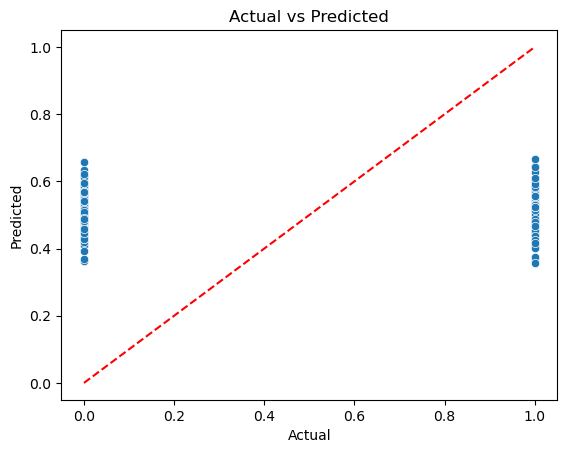

In [56]:
#  Create a plot for linear rigression

sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [57]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
#  Create empty lists to hold our data
features = []
vif_scores = []

#  Use a simple loop to calculate VIF for each column
for i in range(X.shape[1]):
    features.append(X.columns[i])
    score = variance_inflation_factor(X.values, i)
    vif_scores.append(score)

#  Combine them into a DataFrame and sort
vif_data = pd.DataFrame({"Feature": features, "VIF": vif_scores})
vif_data = vif_data.sort_values(by="VIF", ascending=False)

print(vif_data)

                  Feature        VIF
9            region_North  52.984207
10           region_South  51.934914
11            region_West  51.082576
8             region_East  44.877504
2            credit_score   1.024316
5   days_since_last_login   1.020914
1                  income   1.014887
7            num_products   1.013547
4      avg_purchase_value   1.013047
0                     age   1.011350
3      transactions_month   1.010411
6           tenure_months   1.005410


Actually hear some multicolinearity so we can drop one column like a  eg  region_East  this column after we check  the  VIF

In [58]:
# 1. Drop one region column (e.g., 'region_East') to escape the trap
X = X.drop(columns=['region_East'])

# 2. Re-run your VIF loop to verify
features = []
vif_scores = []

for i in range(X.shape[1]):
    features.append(X.columns[i])
    score = variance_inflation_factor(X.values, i)
    vif_scores.append(score)

vif_data = pd.DataFrame({"Feature": features, "VIF": vif_scores})
print(vif_data.sort_values(by="VIF", ascending=False))

                  Feature        VIF
2            credit_score  43.651053
3      transactions_month  29.106141
1                  income  13.106623
4      avg_purchase_value  11.460493
0                     age   9.473871
7            num_products   5.818293
6           tenure_months   4.134103
5   days_since_last_login   3.893741
8            region_North   2.172953
9            region_South   2.157187
10            region_West   2.130800


# RIDGE(L2)---&---LASSO(L1)

In [61]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Step 1: Train the models FIRST
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)

# ==========================
# Step 2: Evaluate RIDGE Model
# ==========================
y_pred_ridge = ridge_model.predict(X_test)

print("--- RIDGE (L2) METRICS ---")
print("R2 Score :", r2_score(y_test, y_pred_ridge))
print("MAE      :", mean_absolute_error(y_test, y_pred_ridge))
print("MSE      :", mean_squared_error(y_test, y_pred_ridge))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

print("\n" + "=" * 30 + "\n")

# ==========================
# Step 3: Evaluate LASSO Model
# ==========================
y_pred_lasso = lasso_model.predict(X_test)

print("--- LASSO (L1) METRICS ---")
print("R2 Score :", r2_score(y_test, y_pred_lasso))
print("MAE      :", mean_absolute_error(y_test, y_pred_lasso))
print("MSE      :", mean_squared_error(y_test, y_pred_lasso))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))

--- RIDGE (L2) METRICS ---
R2 Score : 0.0008324949987025265
MAE      : 0.494973062676727
MSE      : 0.24892754449859314
RMSE     : 0.4989263918641638


--- LASSO (L1) METRICS ---
R2 Score : -0.0036375932324996807
MAE      : 0.4978121068848741
MSE      : 0.25004119969806216
RMSE     : 0.5000411980007868


In [60]:
# now we can do the prediction part
y_pred = ridge_model.predict(X_test)
print(y_pred)

[0.55404842 0.54765808 0.65586973 0.46398853 0.55143958 0.50970139
 0.54631663 0.52011634 0.54515993 0.53015397 0.40353049 0.49194462
 0.41140907 0.50211503 0.44782499 0.48372098 0.59920044 0.63265789
 0.53638258 0.54058945 0.47358955 0.44085584 0.43990328 0.56818762
 0.54492779 0.46420596 0.60253088 0.42164122 0.45912106 0.36965067
 0.43302873 0.5066325  0.58613161 0.59278615 0.50508709 0.36391893
 0.48218804 0.41049853 0.44473513 0.41819125 0.41802205 0.60827421
 0.4764725  0.43025558 0.43532563 0.48990108 0.54051684 0.55165608
 0.45540859 0.49869932 0.64483486 0.57868277 0.54685179 0.53675584
 0.50331566 0.5450726  0.53222864 0.49088544 0.53662787 0.59773929
 0.47528748 0.57825354 0.46129506 0.42129925 0.5729249  0.58504594
 0.49986228 0.49399158 0.61713214 0.42459691 0.51690132 0.48565764
 0.61326978 0.54720435 0.57554318 0.48763046 0.53576083 0.51934236
 0.44899384 0.4862868  0.45506051 0.57714267 0.51826284 0.52784196
 0.46956059 0.62911646 0.56139046 0.50404924 0.52917176 0.5817

In [64]:
# now we can check the polynominal model 
from sklearn.preprocessing import PolynomialFeatures    

poly = PolynomialFeatures(degree = 2 , include_bias = False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)



polymodel = LinearRegression()
polymodel.fit(X_train_poly, y_train)

y_pred_poly = polymodel.predict(X_test_poly)
#print(f"polynomial {y_pred_poly}")

# . Evaluate the metrics
print("--- POLYNOMIAL REGRESSION METRICS ---")
print("R2 Score :", r2_score(y_test, y_pred_poly))
print("MAE      :", mean_absolute_error(y_test, y_pred_poly))
print("MSE      :", mean_squared_error(y_test, y_pred_poly))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred_poly)))

--- POLYNOMIAL REGRESSION METRICS ---
R2 Score : -0.06305046246468393
MAE      : 0.493602099759999
MSE      : 0.2648430217905095
RMSE     : 0.5146290137472911


This  polynomial model is the worst model  for this data 

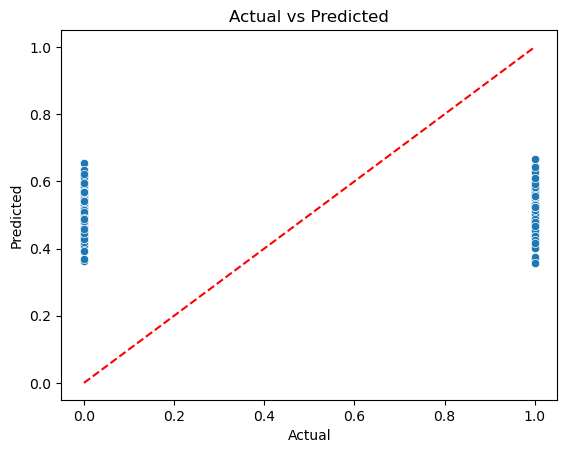

In [65]:
# create a plot for linear regression

sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

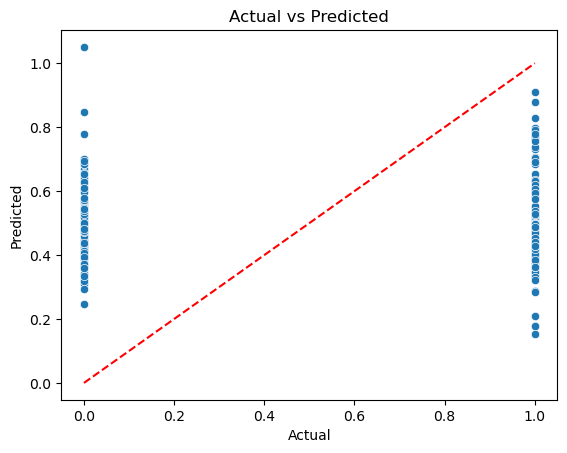

In [66]:
# create a plot for polynomial regression

sns.scatterplot(x=y_test, y=y_pred_poly)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

Decision Tree Regressor (predicting continuous numbers)

Decision Tree Classifier (predicting categories)

Logistic Regression (moving into standard binary classification)

In [ ]:
# Decision Tree (Regressor)
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

dt_model = DecisionTreeRegressor()
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("--- DECISION TREE METRICS ---")
print("R2 Score :", r2_score(y_test, y_pred_dt))
print("MAE      :", mean_absolute_error(y_test, y_pred_dt))
print("MSE      :", mean_squared_error(y_test, y_pred_dt))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred_dt)))

--- DECISION TREE METRICS ---
R2 Score : -1.1679292929292928
MAE      : 0.5401069518716578
MSE      : 0.5401069518716578
RMSE     : 0.7349196907633226


this model worest for this data

In [68]:
# Decision tree classifer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("--- DECISION TREE METRICS ---")
print("Accuracy Score :", accuracy_score(y_test, y_pred_dt))

--- DECISION TREE METRICS ---
Accuracy Score : 0.48128342245989303


In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 10))

plot_tree(
    tree_model,
    feature_names=X.columns,  # Shows your actual column names in the boxes
    filled=True,  # Adds nice color coding
    rounded=True,  # Makes the boxes rounded
    max_depth=3,  # Limits how many levels to show (helpful if the tree is huge)
)

# 3. Display the plot
plt.show()

NameError: name 'tree_model' is not defined

<Figure size 1600x1000 with 0 Axes>

In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_reg = LogisticRegression(random_state=42, max_iter=1000)

log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)

print("--- LOGISTIC REGRESSION METRICS ---")
print("Accuracy Score      :", accuracy_score(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

--- LOGISTIC REGRESSION METRICS ---
Accuracy Score      : 0.5775401069518716

Confusion Matrix:
 [[45 43]
 [36 63]]

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.51      0.53        88
           1       0.59      0.64      0.61        99

    accuracy                           0.58       187
   macro avg       0.57      0.57      0.57       187
weighted avg       0.58      0.58      0.58       187



c:\Users\user\New folder\New folder\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
